# Notebook 1 — Génération Classique (Paramétrique) + XGBoost-B-GHM

**Credit Scoring PME via ERP Wanzo — République Démocratique du Congo**

## Approche
Génération de données synthétiques via **distributions paramétriques expertes** :
- Dirichlet pour les moyens de paiement (cash ~80%, mobile money ~17%, banque ~3%)
- Beta pour les variables CET (Contexte Économique Territorial)
- LogNormale pour le chiffre d'affaires
- Distributions calibrées sur la Persona PME Wanzo (Projet 0 — Chez Manix, Goma)

## Pipeline
1. Génération paramétrique (N=5000)
2. Feature Engineering (ERP + CET + Alternatives)
3. Sélection de features par **Boruta** (Xia et al. 2024)
4. XGBoost avec perte **GHM** (Gradient Harmonizing Mechanism)
5. **Visualisation des arbres** pour l'explicabilité
6. Analyse SHAP

---
**Références** : Xia et al. (2024) — XGBoost-B-GHM ; Nguyen & Sagara (2020) — ADBI WP1111 ; Persona Wanzo CET

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib Boruta shap graphviz --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, average_precision_score, brier_score_loss
)
import xgboost as xgb
import joblib
from boruta import BorutaPy

print("Bibliothèques importées")

✅ Bibliothèques importées


## 1. Génération de données synthétiques — Approche Paramétrique Classique

Simulation basée sur des **distributions statistiques calibrées par expertise métier** :
- Chaque variable est générée indépendamment selon une loi paramétrée
- Les corrélations sont introduites via la variable cible (logit multi-composantes)
- Avantage : contrôle total, interprétabilité des paramètres
- Limite : les corrélations inter-variables ne sont pas capturées

In [3]:
np.random.seed(42)
N = 5000  # Nombre de PME

# === Caractéristiques de l'entreprise (profil ERP) ===
secteurs = ['Commerce', 'Agriculture', 'Manufacture', 'Services', 'Construction', 'Transport', 'TIC', 'Mines']
secteur = np.random.choice(secteurs, N, p=[0.30, 0.20, 0.15, 0.15, 0.08, 0.05, 0.04, 0.03])

tailles = ['Micro', 'Petite', 'Moyenne']
taille = np.random.choice(tailles, N, p=[0.50, 0.35, 0.15])

villes = ['Kinshasa', 'Lubumbashi', 'Goma', 'Bukavu', 'Mbuji-Mayi', 'Kisangani', 'Matadi', 'Kolwezi']
localisation = np.random.choice(villes, N, p=[0.30, 0.20, 0.12, 0.10, 0.08, 0.08, 0.07, 0.05])

anciennete_annees = np.random.exponential(5, N).clip(0.5, 30).round(1)
nb_employes = np.random.lognormal(mean=2, sigma=0.8, size=N).clip(1, 200).astype(int)

# === Données transactionnelles ERP ===
chiffre_affaires = np.random.lognormal(mean=16.5, sigma=1.2, size=N).clip(5e5, 5e8).round(0)
nb_transactions_mois = np.random.poisson(lam=80, size=N).clip(5, 500)
montant_moyen_transaction = (chiffre_affaires / (nb_transactions_mois * 12)).round(0)

# Moyens de paiement, Dirichlet (Persona Wanzo : cash ~80%, MM ~17%, banque ~3%)
payment_mix = np.random.dirichlet([24, 5.1, 0.9], N)
pct_cash = payment_mix[:, 0].round(4)
pct_mobile_money = payment_mix[:, 1].round(4)
pct_banque = payment_mix[:, 2].round(4)
diversification_paiement = (1 - (pct_cash**2 + pct_mobile_money**2 + pct_banque**2)).round(4)
pct_transactions_usd = np.random.beta(3, 3, N).round(4)

# === Trésorerie ERP ===
charges_exploitation = (chiffre_affaires * np.random.uniform(0.55, 0.92, N)).round(0)
resultat_net = chiffre_affaires - charges_exploitation
marge_nette = (resultat_net / chiffre_affaires).round(4)
solde_caisse_moyen = (chiffre_affaires * np.random.uniform(0.02, 0.15, N)).round(0)
entrees_tresorerie_mois = (chiffre_affaires / 12 * np.random.uniform(0.8, 1.2, N)).round(0)
sorties_tresorerie_mois = (entrees_tresorerie_mois * np.random.uniform(0.75, 1.05, N)).round(0)
flux_tresorerie_net = entrees_tresorerie_mois - sorties_tresorerie_mois
remboursements_dettes_mois = (entrees_tresorerie_mois * np.random.beta(2, 8, N)).round(0)
variabilite_ca = np.random.beta(2, 5, N).round(4)
ratio_liquidite = np.random.lognormal(0, 0.5, N).clip(0.1, 5).round(2)
ratio_endettement = np.random.lognormal(0.3, 0.7, N).clip(0, 8).round(2)
couverture_dette = np.random.normal(1.5, 0.8, N).clip(-1, 5).round(2)

# === Comportement de paiement ERP ===
nb_retards_paiement_12m = np.random.poisson(lam=2, size=N).clip(0, 15)
jours_retard_moyen = np.random.exponential(15, N).clip(0, 90).round(0)
nb_factures_impayees = np.random.poisson(lam=3, size=N).clip(0, 20)
taux_recouvrement_creances = np.random.beta(5, 2, N).round(4)
delai_paiement_fournisseurs = np.random.normal(45, 15, N).clip(10, 120).round(0)
delai_recouvrement_jours = np.random.normal(60, 25, N).clip(15, 180).round(0)
creances_sur_ca = np.random.lognormal(-0.3, 0.5, N).clip(0, 3).round(4)
regularite_paiement_mobile = np.random.beta(4, 2, N).round(4)
regularite_paiement_fournisseurs = np.random.beta(3, 2, N).round(4)

# === Variables contextuelles CET (Persona Wanzo, RDC) ===
pct_activite_informelle = np.random.beta(5, 2, N).round(4)
ecart_taux_change = np.random.exponential(0.05, N).clip(0, 0.3).round(4)
appartenance_association = np.random.binomial(1, 0.4, N)
score_reseau_communautaire = np.random.beta(4, 3, N).round(4)
pct_clients_recurrents = np.random.beta(4, 2, N).round(4)
score_reputation_terrain = np.random.beta(5, 2, N).round(4)
part_credit_informel = np.random.beta(2, 3, N).round(4)
exposition_zones_instables = np.random.beta(2, 5, N).round(4)
diversification_activites = np.random.beta(3, 4, N).round(4)
stock_securite_jours = np.random.exponential(15, N).clip(0, 90).round(0)
score_debrouillardise = np.random.beta(5, 3, N).round(4)
usage_whatsapp_business = np.random.binomial(1, 0.35, N)

# === Données alternatives ===
social_media_abonnes = np.random.lognormal(5, 2, N).clip(0, 100000).round(0)
social_media_sentiment = np.random.normal(0.2, 0.3, N).clip(-1, 1).round(4)
social_media_freq_publication = np.random.poisson(lam=8, size=N).clip(0, 60)
conso_energie_kwh = np.random.lognormal(6, 1, N).clip(50, 50000).round(0)
tendance_energie = np.random.normal(0, 0.1, N).clip(-0.5, 0.5).round(4)
conso_eau_m3 = np.random.lognormal(3, 0.8, N).clip(5, 5000).round(0)
trafic_web_mensuel = np.random.lognormal(6, 2, N).clip(0, 500000).round(0)
nb_avis_en_ligne = np.random.poisson(lam=10, size=N).clip(0, 100)
note_avis_moyenne = np.random.normal(3.5, 0.8, N).clip(1, 5).round(1)
regularite_paiement_energie = np.random.beta(4, 2, N).round(4)
regularite_paiement_eau = np.random.beta(3, 2, N).round(4)
regularite_paiement_loyer = np.random.beta(4, 3, N).round(4)

print(f"{N} PME générées via distributions paramétriques")
print(f"   Méthode : Dirichlet, Beta, LogNormale, Poisson, Exponentielle")
print(f"   Seed : 42 (reproductibilité)")

✅ 5000 PME générées via distributions paramétriques
   Méthode : Dirichlet, Beta, LogNormale, Poisson, Exponentielle
   Seed : 42 (reproductibilité)


In [4]:
# --- Variable cible : défaut de paiement ---
# Logique basée sur :
# 1) Littérature académique (ADBI WP1111, MDPI Xia et al. 2024), prédicteurs ERP
# 2) Corrections contextuelles Wanzo (Persona CET), le contexte RDC modifie les signaux
# v2 : composantes CONTINUES + seuils binaires pour renforcer le signal

logit_raw = (
    # === Prédicteurs financiers ERP ===
    + 0.20 * ratio_endettement
    + 0.8  * (ratio_endettement > 2).astype(float)
    - 3.0  * marge_nette
    + 0.15 * nb_retards_paiement_12m
    + 0.5  * (nb_retards_paiement_12m > 3).astype(float)
    + 0.015 * jours_retard_moyen
    + 0.4  * (jours_retard_moyen > 30).astype(float)
    - 2.0  * (solde_caisse_moyen / chiffre_affaires.clip(min=1))
    + 0.4  * (remboursements_dettes_mois > entrees_tresorerie_mois * 0.3).astype(float)
    - 1.2  * taux_recouvrement_creances
    + 0.3  * (taux_recouvrement_creances < 0.5).astype(float)
    - 0.5  * couverture_dette.clip(-2, 2)
    + 2.5  * variabilite_ca
    # === Comportement de paiement ERP ===
    - 1.0  * regularite_paiement_fournisseurs
    - 0.5  * regularite_paiement_mobile
    + 0.12 * nb_factures_impayees
    # === Mobile Money ===
    - 0.8  * pct_mobile_money
    # === Corrections contextuelles CET (Persona Wanzo) ===
    - 0.8  * score_reseau_communautaire
    - 0.4  * appartenance_association.astype(float)
    - 0.6  * pct_clients_recurrents
    - 0.4  * score_reputation_terrain
    - 0.3  * score_debrouillardise
    + 1.2  * exposition_zones_instables
    - 0.01 * stock_securite_jours.clip(0, 60)
    # === Données alternatives ===
    - 0.4  * social_media_sentiment
    - 0.6  * regularite_paiement_energie
    - 0.6  * regularite_paiement_eau
    - 0.04 * anciennete_annees.clip(0, 20)
    - 0.15 * (note_avis_moyenne - 2.5)
    - 0.2  * usage_whatsapp_business.astype(float)
    + np.random.normal(0, 0.5, N)
)

# Auto-calibration : recherche binaire de l'intercept pour 13% de défaut
target_default_rate = 0.13
lo, hi = -10.0, 10.0
for _ in range(60):
    mid = (lo + hi) / 2
    if np.mean(1 / (1 + np.exp(-(logit_raw + mid)))) > target_default_rate:
        hi = mid
    else:
        lo = mid
logit = logit_raw + mid

prob_default = 1 / (1 + np.exp(-logit))
default = (np.random.uniform(0, 1, N) < prob_default).astype(int)

print(f"Taux de défaut : {default.mean()*100:.1f}%")
print(f"  - Défauts : {default.sum()}")
print(f"  - Non-défauts : {(1-default).sum()}")
print(f"\nSignal v2 : composantes continues + seuils binaires")
print(f"   : Écart-type logit = {logit.std():.2f}")
print(f"   : Intercept auto-calibré = {mid:.3f}")

Taux de défaut : 12.8%
  - Défauts : 641
  - Non-défauts : 4359

📊 Signal v2 : composantes continues + seuils binaires
   → Écart-type logit = 1.27
   → Intercept auto-calibré = 1.274


In [5]:
data = pd.DataFrame({
    'secteur': secteur, 'taille': taille, 'localisation': localisation,
    'anciennete_annees': anciennete_annees, 'nb_employes': nb_employes,
    'chiffre_affaires': chiffre_affaires, 'nb_transactions_mois': nb_transactions_mois,
    'montant_moyen_transaction': montant_moyen_transaction,
    'pct_cash': pct_cash, 'pct_mobile_money': pct_mobile_money,
    'pct_banque': pct_banque, 'diversification_paiement': diversification_paiement,
    'pct_transactions_usd': pct_transactions_usd,
    'charges_exploitation': charges_exploitation, 'resultat_net': resultat_net,
    'marge_nette': marge_nette, 'solde_caisse_moyen': solde_caisse_moyen,
    'entrees_tresorerie_mois': entrees_tresorerie_mois,
    'sorties_tresorerie_mois': sorties_tresorerie_mois,
    'flux_tresorerie_net': flux_tresorerie_net,
    'remboursements_dettes_mois': remboursements_dettes_mois,
    'variabilite_ca': variabilite_ca, 'ratio_liquidite': ratio_liquidite,
    'ratio_endettement': ratio_endettement, 'couverture_dette': couverture_dette,
    'nb_retards_paiement_12m': nb_retards_paiement_12m,
    'jours_retard_moyen': jours_retard_moyen,
    'nb_factures_impayees': nb_factures_impayees,
    'taux_recouvrement_creances': taux_recouvrement_creances,
    'delai_paiement_fournisseurs': delai_paiement_fournisseurs,
    'delai_recouvrement_jours': delai_recouvrement_jours,
    'creances_sur_ca': creances_sur_ca,
    'regularite_paiement_mobile': regularite_paiement_mobile,
    'regularite_paiement_fournisseurs': regularite_paiement_fournisseurs,
    'pct_activite_informelle': pct_activite_informelle,
    'ecart_taux_change': ecart_taux_change,
    'appartenance_association': appartenance_association,
    'score_reseau_communautaire': score_reseau_communautaire,
    'pct_clients_recurrents': pct_clients_recurrents,
    'score_reputation_terrain': score_reputation_terrain,
    'part_credit_informel': part_credit_informel,
    'exposition_zones_instables': exposition_zones_instables,
    'diversification_activites': diversification_activites,
    'stock_securite_jours': stock_securite_jours,
    'score_debrouillardise': score_debrouillardise,
    'usage_whatsapp_business': usage_whatsapp_business,
    'social_media_abonnes': social_media_abonnes,
    'social_media_sentiment': social_media_sentiment,
    'social_media_freq_publication': social_media_freq_publication,
    'conso_energie_kwh': conso_energie_kwh, 'tendance_energie': tendance_energie,
    'conso_eau_m3': conso_eau_m3, 'trafic_web_mensuel': trafic_web_mensuel,
    'nb_avis_en_ligne': nb_avis_en_ligne, 'note_avis_moyenne': note_avis_moyenne,
    'regularite_paiement_energie': regularite_paiement_energie,
    'regularite_paiement_eau': regularite_paiement_eau,
    'regularite_paiement_loyer': regularite_paiement_loyer,
    'default': default
})

print(f"DataFrame créé : {data.shape[0]} lignes × {data.shape[1]} colonnes")
print(f"   Taux de défaut : {data['default'].mean()*100:.1f}%")

# Sauvegarder les données brutes pour le Notebook 2 (CTGAN)
data.to_csv('data/data_classique_seed.csv', index=False)
print(f"\nDonnées sauvegardées : data/data_classique_seed.csv (pour comparaison CTGAN)")
data.head()

✅ DataFrame créé : 5000 lignes × 59 colonnes
   Taux de défaut : 12.8%

💾 Données sauvegardées → data_classique_seed.csv (pour comparaison CTGAN)


,secteur,taille,localisation,anciennete_annees,nb_employes,chiffre_affaires,nb_transactions_mois,montant_moyen_transaction,pct_cash,pct_mobile_money,...,conso_energie_kwh,tendance_energie,conso_eau_m3,trafic_web_mensuel,nb_avis_en_ligne,note_avis_moyenne,regularite_paiement_energie,regularite_paiement_eau,regularite_paiement_loyer,default
0,Agriculture,Micro,Lubumbashi,3.5,3,99000702.0,75,110001.0,0.8428,0.1542,...,845.0,0.0518,23.0,222.0,6,3.0,0.7422,0.7568,0.7192,0
1,TIC,Micro,Lubumbashi,6.9,11,2993911.0,84,2970.0,0.7885,0.2108,...,165.0,-0.1553,5.0,35.0,9,2.9,0.6243,0.8139,0.6147,0
2,Services,Moyenne,Kinshasa,4.1,21,2666216.0,79,2812.0,0.7983,0.1522,...,469.0,-0.0087,66.0,6854.0,12,3.9,0.6671,0.3862,0.8806,0
3,Manufacture,Micro,Goma,0.5,2,3510078.0,79,3703.0,0.7601,0.2350,...,894.0,0.0272,125.0,2613.0,5,3.6,0.9584,0.6258,0.3668,0
4,Commerce,Moyenne,Lubumbashi,1.0,29,17214540.0,86,16681.0,0.6881,0.2860,...,432.0,-0.0876,49.0,71.0,5,3.4,0.2160,0.3516,0.7379,1


## 1b. Analyse Exploratoire (EDA)

In [ ]:
# === Fig 1 : Distribution des défauts par secteur ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution globale
labels = ['Sain', 'Défaut']
sizes = [data['default'].value_counts()[0], data['default'].value_counts()[1]]
colors_pie = ['#2ecc71', '#e74c3c']
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title(f"Répartition globale (N={len(data)})")

# Taux de défaut par secteur
sector_rates = data.groupby('secteur')['default'].mean().sort_values()
colors_bar = ['#e74c3c' if r > data['default'].mean() else '#3498db' for r in sector_rates]
sector_rates.plot(kind='barh', ax=axes[1], color=colors_bar)
axes[1].set_xlabel('Taux de défaut')
axes[1].set_title('Taux de défaut par secteur')
axes[1].axvline(x=data['default'].mean(), color='black', linestyle='--', alpha=0.5, label=f"Moyenne = {data['default'].mean():.1%}")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('papers/figures/fig1_distribution_defauts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Sains : {sizes[0]} ({sizes[0]/len(data)*100:.1f}%) | Défauts : {sizes[1]} ({sizes[1]/len(data)*100:.1f}%)")

In [ ]:
# === Fig 2 : Matrice de corrélation (variables clés vs défaut) ===
key_vars = ['marge_nette', 'ratio_endettement', 'variabilite_ca', 'nb_retards_paiement_12m',
            'jours_retard_moyen', 'couverture_dette', 'taux_recouvrement_creances',
            'anciennete_annees', 'score_reseau_communautaire', 'default']
corr = data[key_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.3, vmax=0.3, ax=ax, square=True)
ax.set_title('Corrélations entre variables clés et défaut')
plt.tight_layout()
plt.savefig('papers/figures/fig2_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Top corrélations avec default
corr_default = data[key_vars].corr()['default'].drop('default').abs().sort_values(ascending=False)
print("Corrélations avec 'default' (|r|) :")
for feat, val in corr_default.items():
    print(f"  {feat:40s} : {val:.3f}")

In [ ]:
# === Fig 3 : Distributions KDE des variables les plus discriminantes ===
disc_vars = ['marge_nette', 'ratio_endettement', 'variabilite_ca', 'couverture_dette',
             'jours_retard_moyen', 'taux_recouvrement_creances']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(disc_vars):
    ax = axes[i]
    data[data['default'] == 0][var].plot(kind='kde', ax=ax, color='#2ecc71', label='Sain', lw=2)
    data[data['default'] == 1][var].plot(kind='kde', ax=ax, color='#e74c3c', label='Défaut', lw=2)
    ax.set_title(var.replace('_', ' ').title())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distributions KDE : Sain vs Défaut', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('papers/figures/fig3_distributions_cles.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Feature Engineering

In [6]:
# === Ratios transactionnels ERP ===
data['ca_par_employe'] = (data['chiffre_affaires'] / data['nb_employes'].clip(lower=1)).round(0)
data['charges_ratio'] = (data['charges_exploitation'] / data['chiffre_affaires'].clip(lower=1)).round(4)
data['flux_net_ratio'] = (data['flux_tresorerie_net'] / data['entrees_tresorerie_mois'].clip(lower=1)).round(4)
data['intensite_retards'] = data['nb_retards_paiement_12m'] * data['jours_retard_moyen']
data['tresorerie_par_employe'] = (data['solde_caisse_moyen'] / data['nb_employes'].clip(lower=1)).round(0)
data['charge_remboursement_ratio'] = (
    data['remboursements_dettes_mois'] / data['entrees_tresorerie_mois'].clip(lower=1)
).round(4)
data['solde_caisse_ratio'] = (data['solde_caisse_moyen'] / data['chiffre_affaires'].clip(lower=1)).round(4)
data['score_comportement_transactionnel'] = (
    data['regularite_paiement_fournisseurs'] * 0.30 +
    data['regularite_paiement_mobile'] * 0.25 +
    data['taux_recouvrement_creances'] * 0.25 +
    (1 - data['nb_factures_impayees'] / data['nb_factures_impayees'].max()) * 0.20
).round(4)

# === Scores composites CET ===
data['score_reseau_reputation'] = (
    data['score_reseau_communautaire'] * 0.25 +
    data['appartenance_association'] * 0.25 +
    data['pct_clients_recurrents'] * 0.25 +
    data['score_reputation_terrain'] * 0.25
).round(4)
data['score_robustesse_contextuelle'] = (
    data['diversification_activites'] * 0.30 +
    (1 - data['exposition_zones_instables']) * 0.30 +
    (data['stock_securite_jours'] / 90).clip(0, 1) * 0.20 +
    (1 - data['variabilite_ca'] / 0.6).clip(0, 1) * 0.20
).round(4)
data['creances_deviation_norme'] = (data['creances_sur_ca'] / 1.28).round(3)
data['score_psychometrie'] = (
    data['score_debrouillardise'] * 0.50 +
    data['usage_whatsapp_business'] * 0.20 +
    (data['anciennete_annees'] / 30).clip(0, 1) * 0.30
).round(4)

# === Indicateurs alternatifs dérivés ===
data['score_presence_digitale'] = (
    np.log1p(data['social_media_abonnes']) * 0.3 +
    np.log1p(data['trafic_web_mensuel']) * 0.3 +
    data['note_avis_moyenne'] / 5 * 0.2 +
    np.log1p(data['nb_avis_en_ligne']) * 0.2
).round(4)
data['score_regularite_utilites'] = (
    data['regularite_paiement_energie'] * 0.35 +
    data['regularite_paiement_eau'] * 0.30 +
    data['regularite_paiement_loyer'] * 0.35
).round(4)
data['energie_par_employe'] = (data['conso_energie_kwh'] / data['nb_employes'].clip(lower=1)).round(2)
data['eau_par_employe'] = (data['conso_eau_m3'] / data['nb_employes'].clip(lower=1)).round(2)
data['anciennete_log'] = np.log1p(data['anciennete_annees']).round(4)
data['employes_log'] = np.log1p(data['nb_employes']).round(4)

print(f"Features ajoutées, Total : {data.shape[1]} colonnes")

✅ Features ajoutées — Total : 77 colonnes


## 3. Préparation des données + Sélection Boruta

In [7]:
# Séparation features / cible
target = 'default'
cat_vars = ['secteur', 'taille', 'localisation']
X = data.drop(columns=[target])
y = data[target]

# Encodage OneHot
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = pd.DataFrame(
    encoder.fit_transform(X[cat_vars]),
    columns=encoder.get_feature_names_out(cat_vars),
    index=X.index
)
X = pd.concat([X.drop(columns=cat_vars), cat_encoded], axis=1)

# Standardisation
num_features = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

print(f"X shape = {X.shape}")

✅ X shape = (5000, 92)


In [8]:
# === Sélection Boruta (Xia et al. 2024) ===
xgb_boruta = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='auc',
    max_depth=5, learning_rate=0.1, n_estimators=100,
    random_state=42, use_label_encoder=False, verbosity=0
)

boruta_selector = BorutaPy(
    estimator=xgb_boruta, n_estimators='auto',
    max_iter=40, random_state=42, verbose=0
)

print("⏳ Exécution de Boruta (max 40 itérations)...")
boruta_selector.fit(X.values, y.values)

selected_features = X.columns[boruta_selector.support_].tolist()
tentative_features = X.columns[boruta_selector.support_weak_].tolist()
final_features = selected_features + tentative_features

print(f"\nBoruta : {len(selected_features)} confirmées + {len(tentative_features)} tentatives = {len(final_features)} retenues")
for f in sorted(final_features):
    rank = boruta_selector.ranking_[X.columns.tolist().index(f)]
    print(f"   • {f} (rang {rank})")

X = X[final_features]
num_features_boruta = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X[num_features_boruta] = scaler.fit_transform(X[num_features_boruta])
print(f"\nX réduit : {X.shape[1]} features")

⏳ Exécution de Boruta (max 40 itérations)...

✅ Boruta : 6 confirmées + 7 tentatives = 13 retenues
   • anciennete_annees (rang 2)
   • charges_ratio (rang 2)
   • couverture_dette (rang 2)
   • intensite_retards (rang 1)
   • jours_retard_moyen (rang 2)
   • marge_nette (rang 1)
   • nb_retards_paiement_12m (rang 1)
   • ratio_endettement (rang 1)
   • score_comportement_transactionnel (rang 1)
   • score_reseau_reputation (rang 2)
   • score_robustesse_contextuelle (rang 2)
   • taux_recouvrement_creances (rang 2)
   • variabilite_ca (rang 1)

✅ X réduit → 13 features


In [9]:
# Division : 80% train / 10% validation / 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train  : {X_train.shape[0]} ({y_train.mean()*100:.1f}% défauts)")
print(f"Valid  : {X_valid.shape[0]} ({y_valid.mean()*100:.1f}% défauts)")
print(f"Test   : {X_test.shape[0]} ({y_test.mean()*100:.1f}% défauts)")

Train  : 4000 (12.8% défauts)
Valid  : 500 (12.8% défauts)
Test   : 500 (12.8% défauts)


## 4. Modélisation XGBoost-B-GHM

In [10]:
import time

# === GHM Loss Function ===
def ghm_loss(y_true, y_pred, bins=7, beta=0.65):
    sigmoid_pred = 1.0 / (1.0 + np.exp(-y_pred))
    g = np.abs(y_true - sigmoid_pred)
    edges = np.linspace(0, 1, bins + 1)
    weights = np.ones_like(g)
    for i in range(bins):
        mask = (g >= edges[i]) & (g < edges[i + 1])
        count = mask.sum()
        if count > 0:
            density = count / (edges[i + 1] - edges[i])
            weights[mask] = len(g) / (density * bins)
    weights = beta * weights + (1 - beta) * 1.0
    grad = weights * (sigmoid_pred - y_true)
    hess = weights * sigmoid_pred * (1 - sigmoid_pred)
    return grad, hess

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio classe négative/positive : {scale_pos:.2f}")

xgb_clf = xgb.XGBClassifier(
    objective=ghm_loss, eval_metric='auc',
    random_state=42, use_label_encoder=False
)

param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400, 600, 800],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 1.5]
}

print(f"RandomizedSearch : 50 combinaisons × 5 folds")

Ratio classe négative/positive : 6.80
RandomizedSearch : 50 combinaisons × 5 folds


In [11]:
# Recherche d'hyperparamètres
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb_clf, param_distributions=param_grid,
    n_iter=50, cv=skf, scoring='roc_auc',
    n_jobs=-1, verbose=1, random_state=42, return_train_score=True
)

start_time = time.time()
random_search.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
elapsed = time.time() - start_time

print(f"\n⏱️ Temps : {elapsed:.1f}s")
print(f"\n🏆 Meilleurs hyperparamètres :")
for param, val in random_search.best_params_.items():
    print(f"   {param}: {val}")
print(f"\nMeilleur AUC (CV) : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

⏱️ Temps : 447.9s

🏆 Meilleurs hyperparamètres :
   subsample: 0.8
   reg_lambda: 1
   reg_alpha: 0.1
   n_estimators: 600
   min_child_weight: 3
   max_depth: 4
   learning_rate: 0.01
   gamma: 0.3
   colsample_bytree: 0.8

📊 Meilleur AUC (CV) : 0.7659


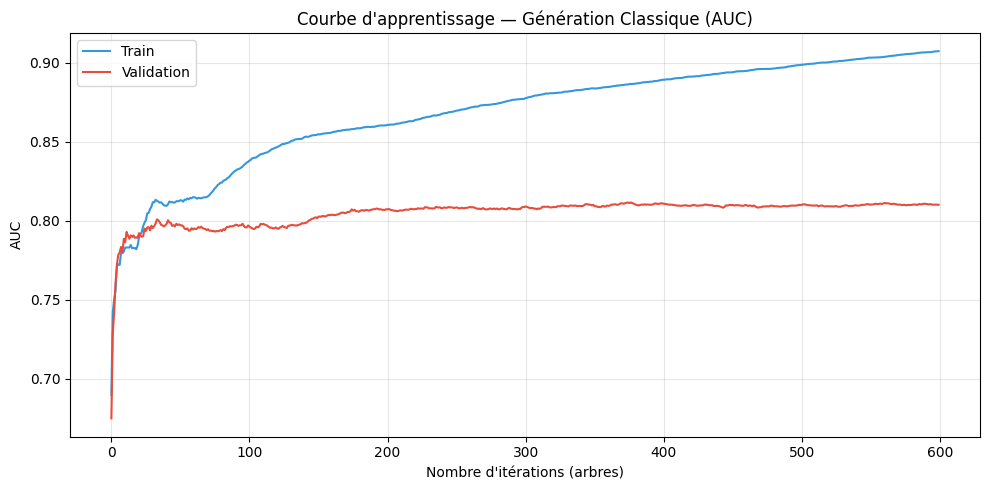

In [ ]:
# Réentraînement du meilleur modèle
best_model = random_search.best_estimator_
eval_set = [(X_train, y_train), (X_valid, y_valid)]
best_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

results = best_model.evals_result()
eval_metric = list(results['validation_0'].keys())[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['validation_0'][eval_metric], label='Train', color='#3498db')
ax.plot(results['validation_1'][eval_metric], label='Validation', color='#e74c3c')
ax.set_xlabel("Nombre d'itérations (arbres)")
ax.set_ylabel(eval_metric.upper())
ax.set_title(f"Courbe d'apprentissage, Génération Classique ({eval_metric.upper()})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('papers/figures/fig4_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Évaluation du modèle

In [ ]:
# Prédictions sur le jeu de test
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("MÉTRIQUES, XGBoost-B-GHM (Génération Classique)")
print("=" * 60)
print(f"\nAccuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision   : {precision_score(y_test, y_pred):.4f}")
print(f"Recall      : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score    : {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC     : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"AUC-PR      : {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"Brier Score : {brier_score_loss(y_test, y_pred_proba):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Sain', 'Défaut']))

# Sauvegarder les métriques pour comparaison
metrics_classique = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba),
    'AUC-PR': average_precision_score(y_test, y_pred_proba),
    'Brier Score': brier_score_loss(y_test, y_pred_proba)
}
joblib.dump(metrics_classique, 'data/metrics_classique.pkl')
print("Métriques sauvegardées : data/metrics_classique.pkl")

MÉTRIQUES — XGBoost-B-GHM (Génération Classique)

Accuracy    : 0.8740
Precision   : 0.5385
Recall      : 0.1094
F1-Score    : 0.1818
AUC-ROC     : 0.7667
AUC-PR      : 0.4219
Brier Score : 0.0952

              precision    recall  f1-score   support

        Sain       0.88      0.99      0.93       436
      Défaut       0.54      0.11      0.18        64

    accuracy                           0.87       500
   macro avg       0.71      0.55      0.56       500
weighted avg       0.84      0.87      0.84       500

💾 Métriques sauvegardées → metrics_classique.pkl


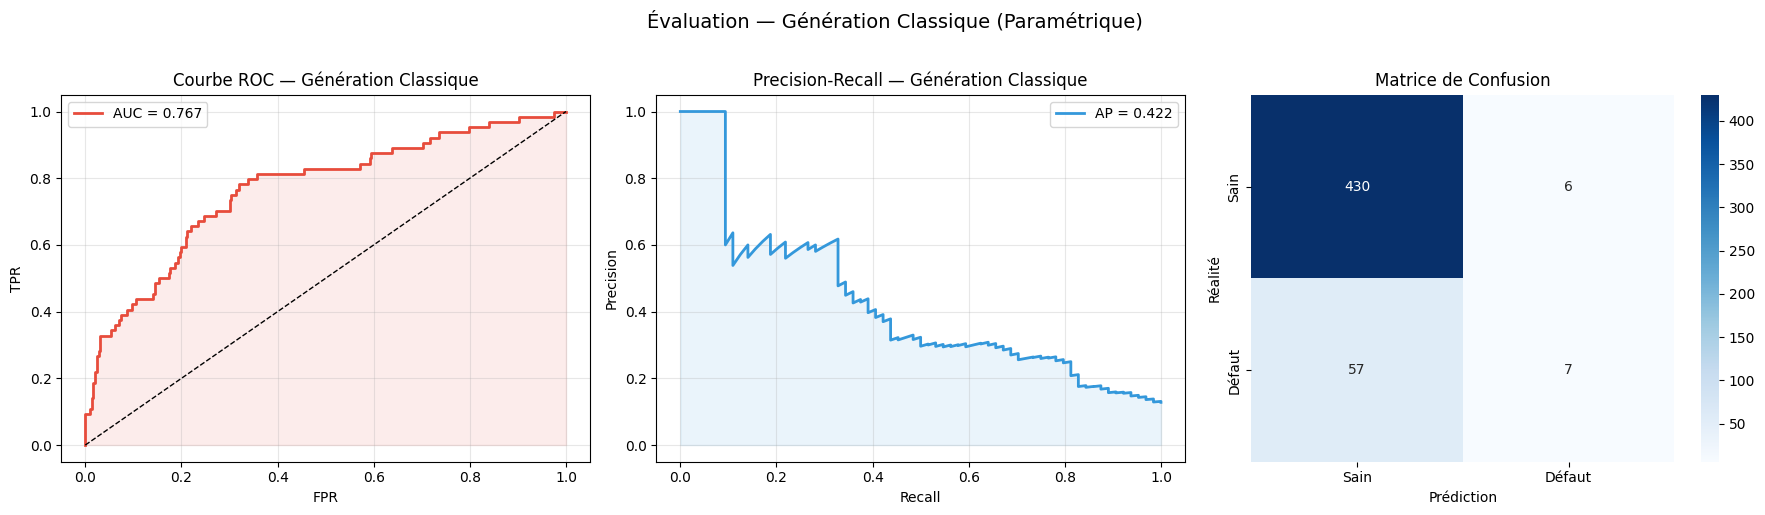

In [ ]:
# Courbe ROC, Precision-Recall, Matrice de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Courbe ROC, Génération Classique')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
ap_score = average_precision_score(y_test, y_pred_proba)
axes[1].plot(recall_vals, precision_vals, color='#3498db', lw=2, label=f'AP = {ap_score:.3f}')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall, Génération Classique')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Sain', 'Défaut'], yticklabels=['Sain', 'Défaut'])
axes[2].set_xlabel('Prédiction'); axes[2].set_ylabel('Réalité')
axes[2].set_title('Matrice de Confusion')

plt.suptitle('Évaluation, Génération Classique (Paramétrique)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('papers/figures/fig5_roc_pr_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

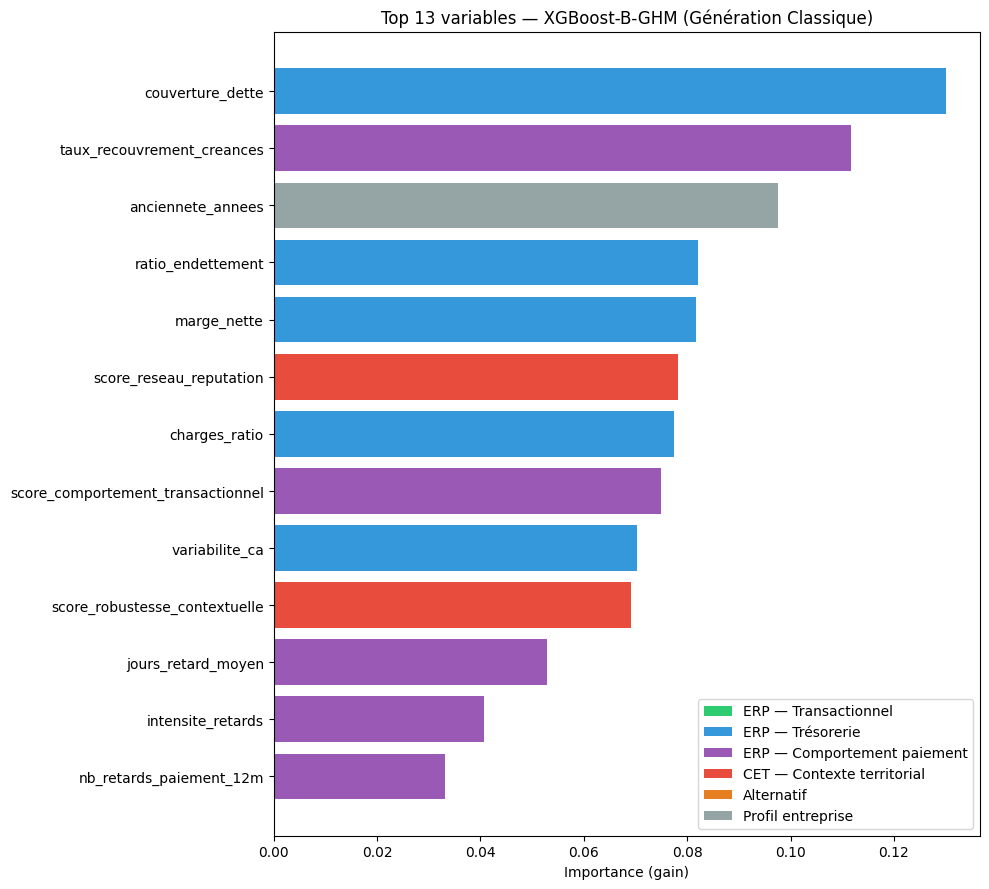

In [ ]:
# Importance des variables
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

def categorize_feature(name):
    contextuel_cet = ['informelle', 'ecart_taux', 'association', 'reseau', 'clients_recurrents',
                      'reputation', 'credit_informel', 'exposition_zones', 'diversification_activites',
                      'stock_securite', 'debrouillardise', 'whatsapp', 'robustesse',
                      'psychometrie', 'creances_deviation']
    erp_transac = ['pct_cash', 'pct_mobile', 'pct_banque', 'diversification', 'nb_transactions',
                   'montant_moyen', 'pct_transactions_usd']
    erp_tresorie = ['chiffre_affaires', 'charges', 'resultat', 'marge', 'flux', 'tresorerie',
                    'solde_caisse', 'entrees', 'sorties', 'remboursements', 'ratio_liquidite',
                    'ratio_endettement', 'couverture', 'ca_par', 'charges_ratio', 'flux_net',
                    'charge_remboursement', 'solde_caisse_ratio', 'variabilite_ca']
    erp_comportement = ['retards', 'jours_retard', 'factures', 'taux_recouvrement', 'delai_paiement',
                        'regularite_paiement_mobile', 'regularite_paiement_fournisseurs',
                        'intensite', 'score_comportement', 'delai_recouvrement', 'creances_sur_ca']
    alternative = ['social', 'conso', 'tendance', 'trafic', 'avis', 'note', 'regularite_paiement_energie',
                   'regularite_paiement_eau', 'regularite_paiement_loyer', 'energie_par', 'eau_par',
                   'score_presence', 'score_regularite_utilites']
    for kw in contextuel_cet:
        if kw in name.lower(): return '#e74c3c'
    for kw in erp_transac:
        if kw in name.lower(): return '#2ecc71'
    for kw in erp_tresorie:
        if kw in name.lower(): return '#3498db'
    for kw in erp_comportement:
        if kw in name.lower(): return '#9b59b6'
    for kw in alternative:
        if kw in name.lower(): return '#e67e22'
    return '#95a5a6'

top_n = min(25, len(feature_importances))
top_features_plot = feature_importances.tail(top_n)
colors = [categorize_feature(f) for f in top_features_plot['Feature']]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_features_plot['Feature'], top_features_plot['Importance'], color=colors)
ax.set_title(f'Top {top_n} variables, XGBoost-B-GHM (Génération Classique)')
ax.set_xlabel('Importance (gain)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='ERP, Transactionnel'),
    Patch(facecolor='#3498db', label='ERP, Trésorerie'),
    Patch(facecolor='#9b59b6', label='ERP, Comportement paiement'),
    Patch(facecolor='#e74c3c', label='CET, Contexte territorial'),
    Patch(facecolor='#e67e22', label='Alternatif'),
    Patch(facecolor='#95a5a6', label='Profil entreprise')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('papers/figures/fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Explicabilité — Visualisation des Arbres XGBoost

Le choix de XGBoost repose sur son **explicabilité** : chaque arbre est un ensemble de règles interprétables.
On visualise ici la structure des arbres de décision individuels du modèle.

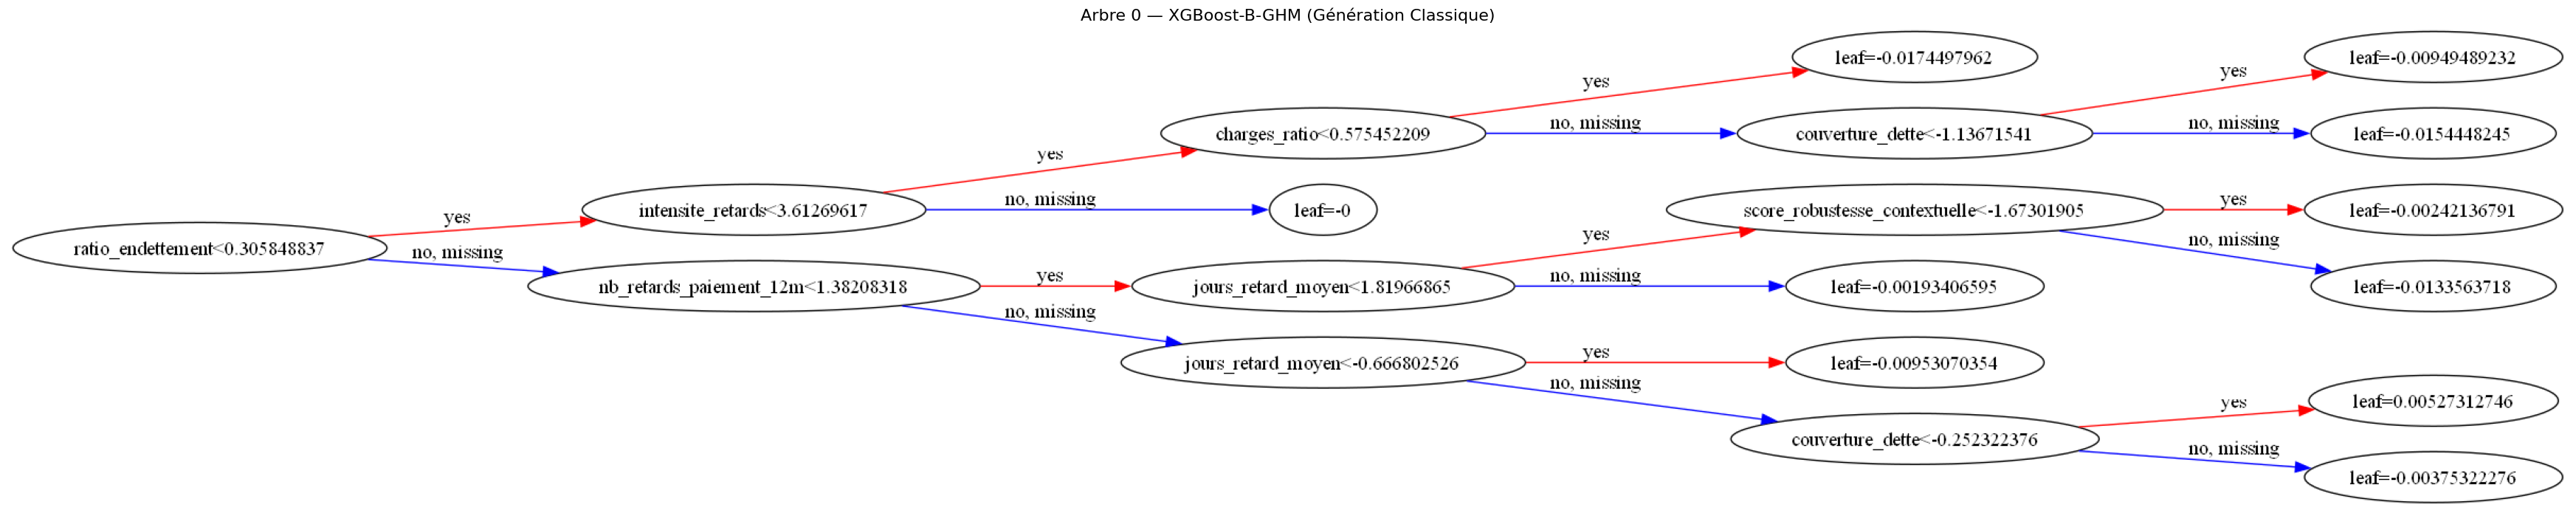

💾 Arbre sauvegardé → arbre_0_classique.png


In [ ]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

# === Visualisation de la structure des arbres XGBoost ===
# Arbre 0 (premier arbre de l'ensemble)
fig, ax = plt.subplots(figsize=(35, 20))
xgb.plot_tree(best_model, num_trees=0, ax=ax, rankdir='LR')
ax.set_title("Arbre 0, XGBoost-B-GHM (Génération Classique)", fontsize=16)
plt.tight_layout()
plt.savefig('papers/figures/arbre_0_classique.png', dpi=150, bbox_inches='tight')
plt.show()
print("Arbre sauvegardé : papers/figures/arbre_0_classique.png")

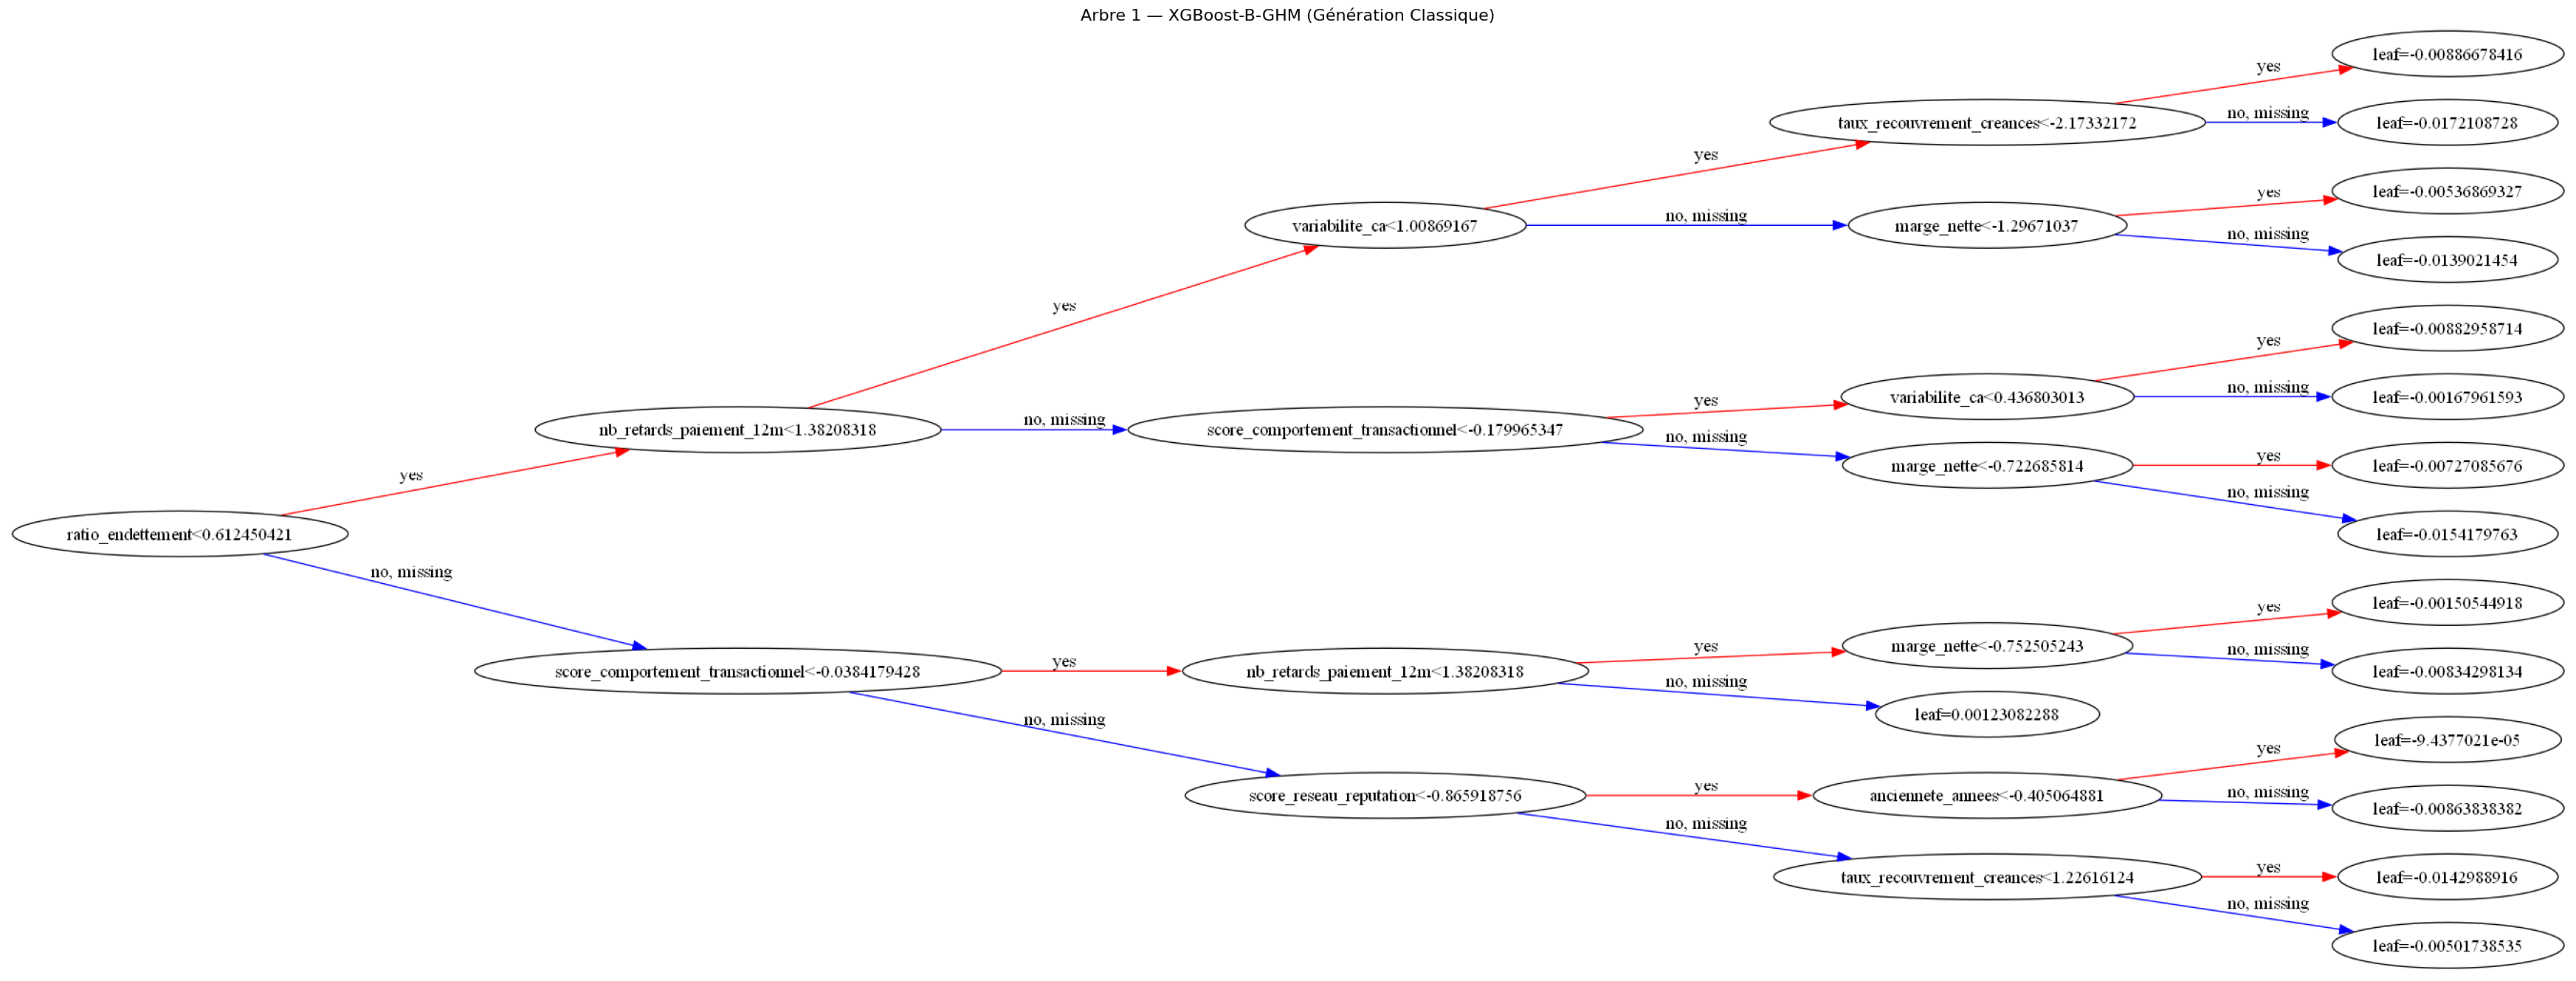

💾 Arbre 1 sauvegardé


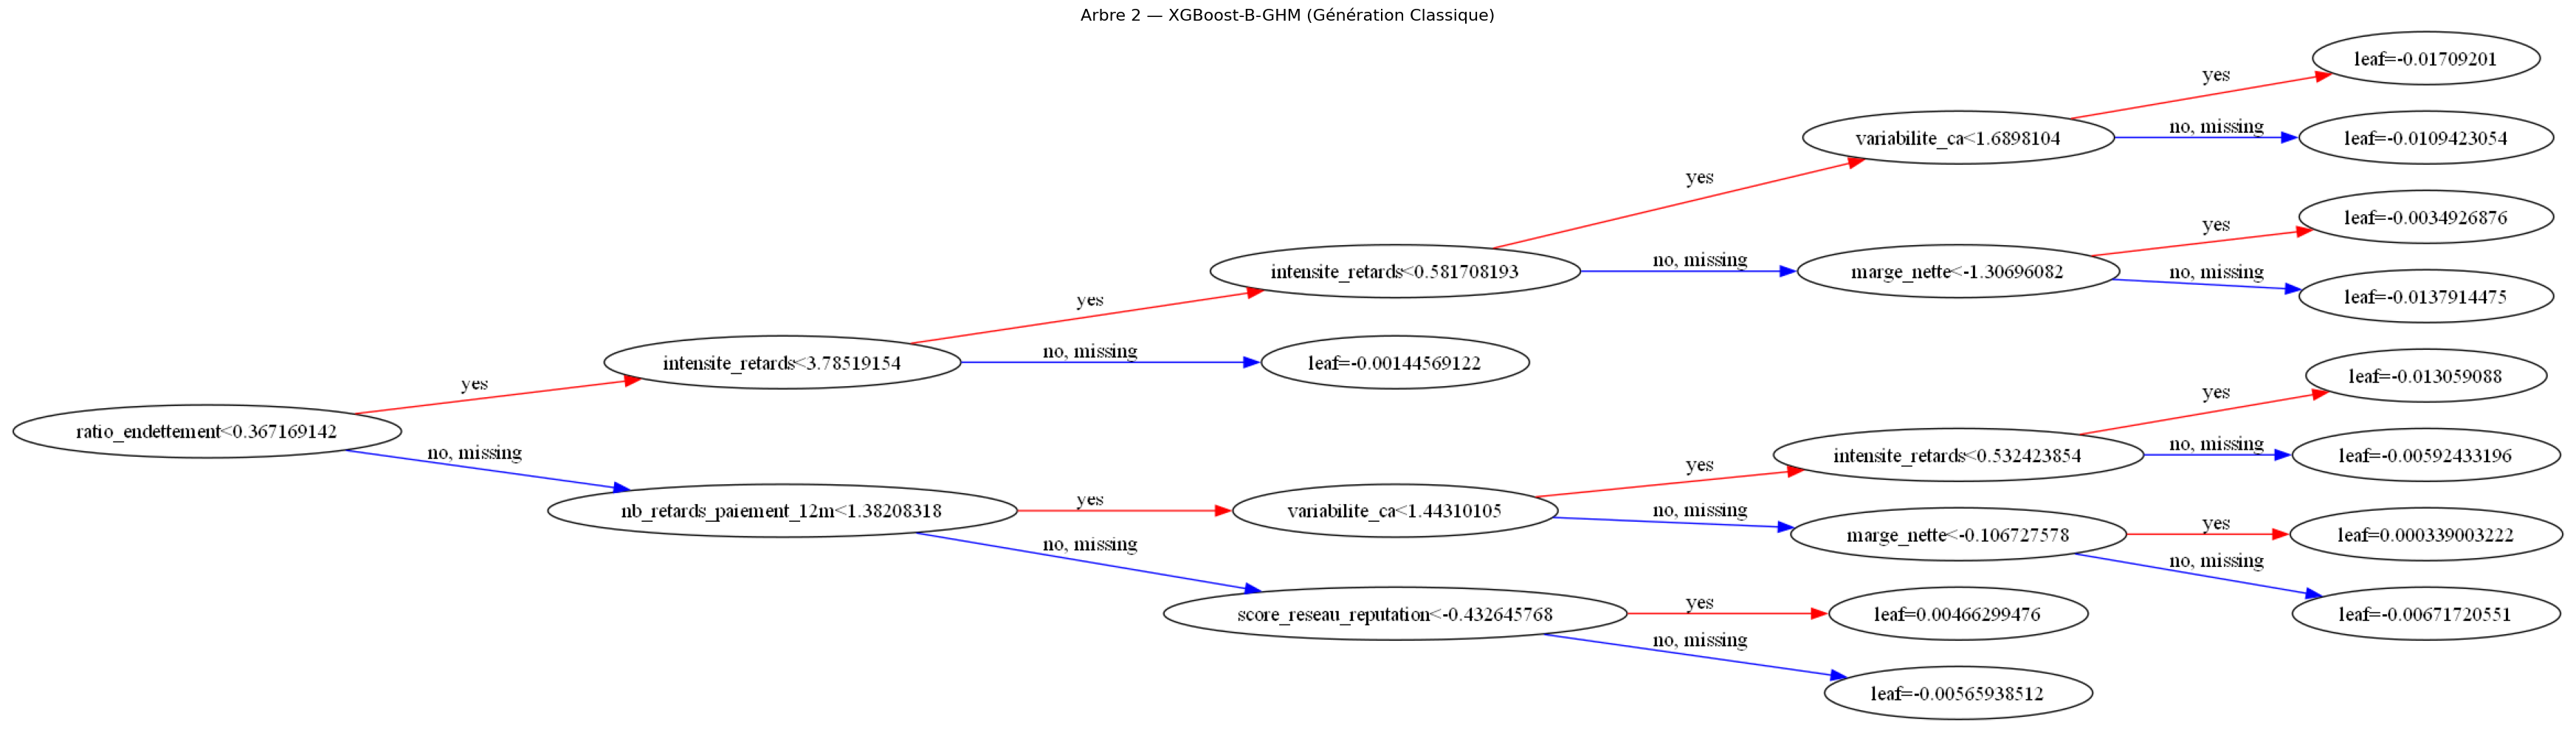

💾 Arbre 2 sauvegardé


In [ ]:
# Arbres 1 et 2 pour voir la diversité des règles de décision
for tree_idx in [1, 2]:
    fig, ax = plt.subplots(figsize=(35, 20))
    xgb.plot_tree(best_model, num_trees=tree_idx, ax=ax, rankdir='LR')
    ax.set_title(f"Arbre {tree_idx}, XGBoost-B-GHM (Génération Classique)", fontsize=16)
    plt.tight_layout()
    plt.savefig(f'papers/figures/arbre_{tree_idx}_classique.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Arbre {tree_idx} sauvegardé")

In [20]:
# === Statistiques sur la structure des arbres ===
booster = best_model.get_booster()
trees_df = booster.trees_to_dataframe()

n_trees = trees_df['Tree'].nunique()

# Calculer la profondeur à partir de l'ID du noeud (format: "0-0", "0-1", etc.)
# La profondeur max par arbre = on calcule via la hiérarchie Yes/No
def tree_max_depth(tree_group):
    """Calcule la profondeur max d'un arbre via parcours des noeuds."""
    depth = {}
    for _, row in tree_group.iterrows():
        depth[row['ID']] = 0
    for _, row in tree_group.iterrows():
        if row['Feature'] != 'Leaf':
            for child_col in ['Yes', 'No', 'Missing']:
                child = row.get(child_col)
                if pd.notna(child) and child in depth:
                    depth[child] = depth.get(row['ID'], 0) + 1
    return max(depth.values()) if depth else 0

depths = trees_df.groupby('Tree').apply(tree_max_depth)
avg_depth = depths.mean()
avg_leaves = trees_df[trees_df['Feature'] == 'Leaf'].groupby('Tree').size().mean()
top_split_features = trees_df[trees_df['Feature'] != 'Leaf']['Feature'].value_counts().head(10)

print("=" * 60)
print("STRUCTURE DU MODÈLE XGBoost, Génération Classique")
print("=" * 60)
print(f"Nombre total d'arbres       : {n_trees}")
print(f"Profondeur moyenne           : {avg_depth:.1f}")
print(f"Nombre moyen de feuilles     : {avg_leaves:.1f}")
print(f"\nTop 10 variables de split :")
for feat, count in top_split_features.items():
    print(f"   {feat:40s} : {count:4d} splits")

STRUCTURE DU MODÈLE XGBoost — Génération Classique
Nombre total d'arbres       : 600
Profondeur moyenne           : 4.0
Nombre moyen de feuilles     : 11.8

Top 10 variables de split :
   ratio_endettement                        :  678 splits
   score_comportement_transactionnel        :  647 splits
   couverture_dette                         :  614 splits
   score_reseau_reputation                  :  609 splits
   intensite_retards                        :  565 splits
   variabilite_ca                           :  546 splits
   score_robustesse_contextuelle            :  522 splits
   marge_nette                              :  520 splits
   taux_recouvrement_creances               :  496 splits
   anciennete_annees                        :  462 splits


## 7. Analyse SHAP

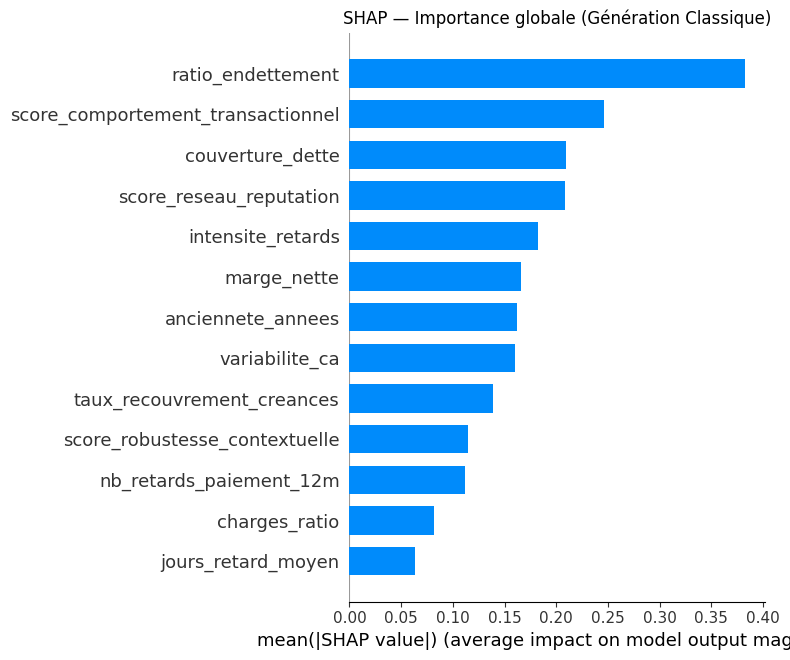

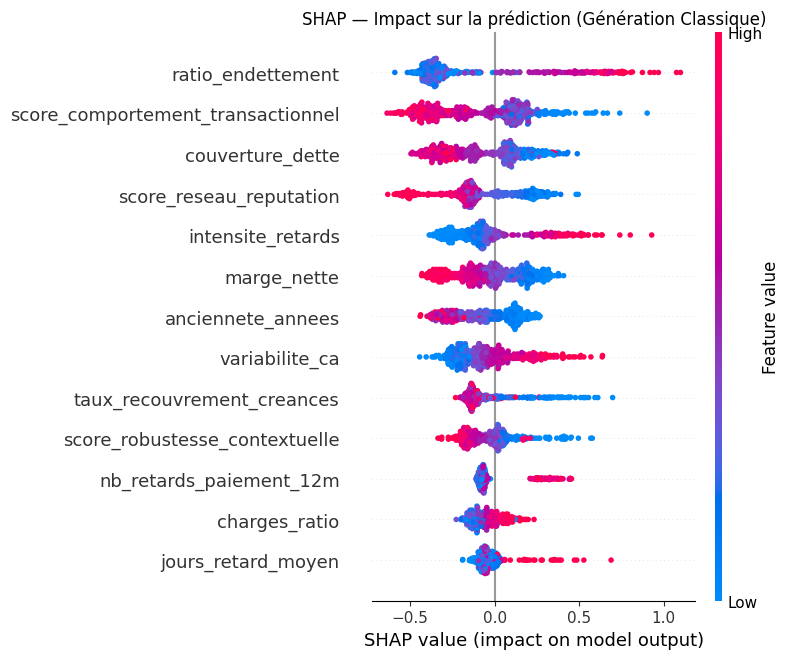

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (bar)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20, show=False)
plt.title('SHAP, Importance globale (Génération Classique)')
plt.tight_layout()
plt.savefig('papers/figures/fig7_shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP, Impact sur la prédiction (Génération Classique)')
plt.tight_layout()
plt.savefig('papers/figures/fig7_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

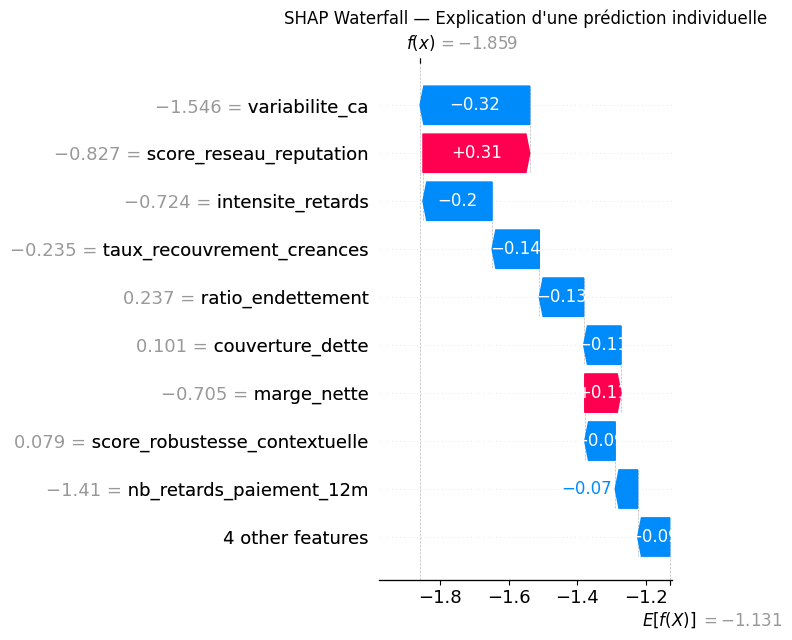

In [22]:
# SHAP, Waterfall plot pour une prédiction individuelle
shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0].values,
    feature_names=X_test.columns.tolist()
)
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP Waterfall, Explication d\'une prédiction individuelle')
plt.tight_layout()
plt.show()

## 8. Credit Scoring (300-850)

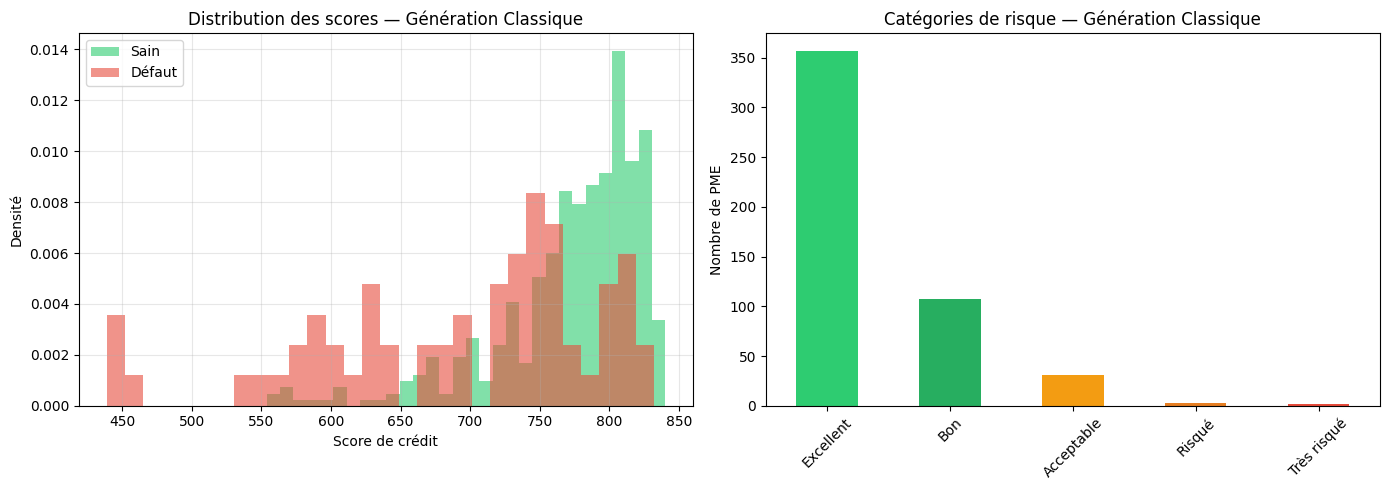


📊 Répartition des catégories de risque :
  Excellent       :  357 PME ( 71.4%) — Taux défaut : 6.2%
  Bon             :  107 PME ( 21.4%) — Taux défaut : 19.6%
  Acceptable      :   31 PME (  6.2%) — Taux défaut : 51.6%
  Risqué          :    3 PME (  0.6%) — Taux défaut : 100.0%
  Très risqué     :    2 PME (  0.4%) — Taux défaut : 100.0%


In [ ]:
def probability_to_credit_score(prob_default, min_score=300, max_score=850):
    return ((1 - prob_default) * (max_score - min_score) + min_score).round(0).astype(int)

def get_risk_category(score):
    if score >= 750: return 'Excellent'
    elif score >= 650: return 'Bon'
    elif score >= 550: return 'Acceptable'
    elif score >= 450: return 'Risqué'
    else: return 'Très risqué'

scores = probability_to_credit_score(y_pred_proba)
risk_categories = pd.Series(scores).apply(get_risk_category)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores[y_test == 0], bins=30, alpha=0.6, color='#2ecc71', label='Sain', density=True)
axes[0].hist(scores[y_test == 1], bins=30, alpha=0.6, color='#e74c3c', label='Défaut', density=True)
axes[0].set_xlabel('Score de crédit'); axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution des scores, Génération Classique')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

cat_counts = risk_categories.value_counts().reindex(['Excellent', 'Bon', 'Acceptable', 'Risqué', 'Très risqué'])
colors_cat = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
cat_counts.plot(kind='bar', ax=axes[1], color=colors_cat)
axes[1].set_title('Catégories de risque, Génération Classique')
axes[1].set_ylabel('Nombre de PME')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('papers/figures/fig8_scores_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRépartition des catégories de risque :")
for cat in ['Excellent', 'Bon', 'Acceptable', 'Risqué', 'Très risqué']:
    mask = risk_categories == cat
    count = mask.sum()
    if count > 0:
        default_rate = y_test.values[mask.values].mean() * 100
        print(f"  {cat:15s} : {count:4d} PME ({count/len(scores)*100:5.1f}%), Taux défaut : {default_rate:.1f}%")

## 9. Sauvegarde du modèle

In [ ]:
# Sauvegarde complète
model_artifacts = {
    'model': best_model,
    'encoder': encoder,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'best_params': random_search.best_params_,
    'best_auc_cv': random_search.best_score_,
    'boruta_selected': final_features,
    'metrics': metrics_classique,
    'generation_method': 'parametric_classical',
    'metadata': {
        'version': 'v3.0-classique',
        'model_type': 'XGBoost-Boruta-GHM',
        'data_generation': 'Distributions paramétriques (Dirichlet, Beta, LogNormale, Poisson)',
        'N': N,
        'n_features_boruta': len(final_features),
        'description': 'Notebook 1, Génération classique paramétrique'
    }
}

joblib.dump(model_artifacts, 'models/model_classique_xgboost_bghm.pkl')
best_model.save_model('models/model_classique_xgboost_bghm.json')
print("Modèle Classique sauvegardé")
print(f"   : models/model_classique_xgboost_bghm.pkl")
print(f"   : models/model_classique_xgboost_bghm.json")
print(f"   : data/metrics_classique.pkl")
print(f"   : data/data_classique_seed.csv")

✅ Modèle Classique sauvegardé
   → model_classique_xgboost_bghm.pkl
   → model_classique_xgboost_bghm.json
   → metrics_classique.pkl
   → data_classique_seed.csv
